# Global and localized TwoNN on the lollipop dataset

This notebook uses the `skdim.id.TwoNN` estimator and the `lollipop_dataset_0` generator from the LIDL paper repository.

In [1]:
from pathlib import Path
import subprocess
import sys
import matplotlib.pyplot as plt
import numpy as np
import skdim
from matplotlib.colors import Normalize

LIDL_DIR = Path.cwd() / "lidl"
if not (LIDL_DIR / ".git").exists():
    subprocess.run(
        ["git", "clone", "--quiet", "https://github.com/opium-sh/lidl.git", str(LIDL_DIR)],
        check=True,
    )
sys.path.insert(0, str(LIDL_DIR))
DISCARD_FRACTION = 0.10
OUTPUT_PATH = Path("fig/lollipop_lid_estimate.pdf")

In [2]:
from datasets import lollipop_dataset_0
data = lollipop_dataset_0(1000, seed=0)

In [3]:
global_estimator = skdim.id.TwoNN(discard_fraction=DISCARD_FRACTION)
global_estimator.fit(data)
global_id = global_estimator.dimension_

local_estimator = skdim.id.TwoNN(discard_fraction=DISCARD_FRACTION)
local_estimator.fit_pw(data, n_neighbors=32)
local_id = local_estimator.dimension_pw_

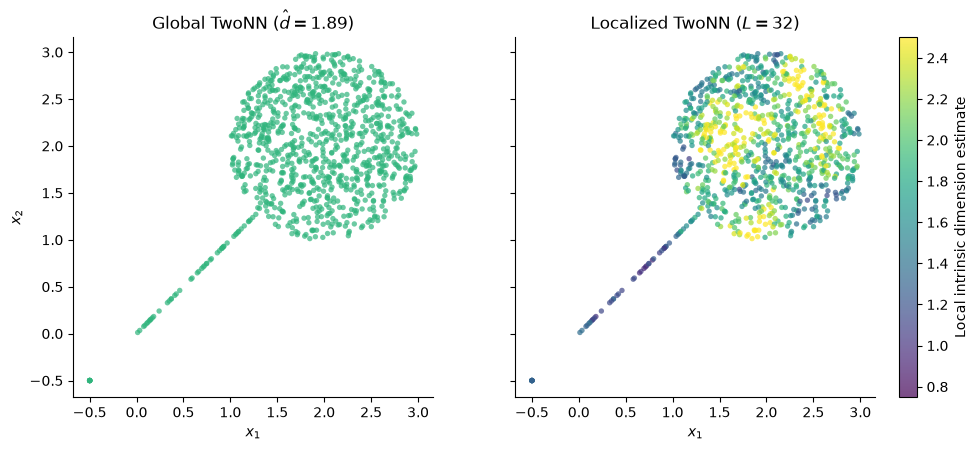

Saved figure to /run/media/anton/B834B14B34B10CFE/Linux/parameter-golf-lid-analysis/fig/lollipop_lid_estimate.pdf


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6), sharex=True, sharey=True)

color_norm = Normalize(vmin=0.75, vmax=2.50, clip=False)
cmap = plt.get_cmap("viridis")
global_color_values = np.full(data.shape[0], global_id, dtype=float)
axes[0].scatter(
    data[:, 0],
    data[:, 1],
    c=global_color_values,
    cmap=cmap,
    norm=color_norm,
    s=15,
    alpha=0.70,
    linewidths=0,
)
axes[0].set_title(rf"Global TwoNN ($\hat{{d}}={global_id:.2f}$)")
axes[0].set_ylabel(r"$x_2$")

local_scatter = axes[1].scatter(
    data[:, 0],
    data[:, 1],
    c=local_id,
    cmap=cmap,
    norm=color_norm,
    s=15,
    alpha=0.70,
    linewidths=0,
)
axes[1].set_title(rf"Localized TwoNN ($L={32}$)")

for ax in axes:
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$x_1$")
    ax.spines[["top", "right"]].set_visible(False)

colorbar = fig.colorbar(
    local_scatter, ax=axes[1], label="Local intrinsic dimension estimate"
)
fig.tight_layout()

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_PATH, format="pdf", bbox_inches="tight")
plt.show()
print(f"Saved figure to {OUTPUT_PATH.resolve()}")